In [88]:
install.packages("devtools")
install.packages("robust")


The downloaded binary packages are in
	/var/folders/gh/wjs3pzl11758g8crdf96rf8c0000gn/T//RtmpurLBdX/downloaded_packages

The downloaded binary packages are in
	/var/folders/gh/wjs3pzl11758g8crdf96rf8c0000gn/T//RtmpurLBdX/downloaded_packages


In [4]:
library(devtools)
install_github("radamsRHA/ROBRT")

Loading required package: usethis




cpp11        (0.5.2  -> 0.5.3 ) [CRAN]
vctrs        (0.6.5  -> 0.7.1 ) [CRAN]
rlang        (1.1.6  -> 1.1.7 ) [CRAN]
magrittr     (2.0.3  -> 2.0.4 ) [CRAN]
lifecycle    (1.0.4  -> 1.0.5 ) [CRAN]
Rcpp         (1.0.14 -> 1.1.1 ) [CRAN]
igraph       (2.1.4  -> 2.2.2 ) [CRAN]
fastmatch    (1.1-6  -> 1.1-8 ) [CRAN]
digest       (0.6.37 -> 0.6.39) [CRAN]
DEoptimR     (NA     -> 1.1-4 ) [CRAN]
pcaPP        (NA     -> 2.0-5 ) [CRAN]
robustbase   (NA     -> 0.99-7) [CRAN]
scatterpl... (0.3-44 -> 0.3-45) [CRAN]
mnormt       (2.1.1  -> 2.1.2 ) [CRAN]
rrcov        (NA     -> 1.7-7 ) [CRAN]
fit.models   (NA     -> 0.64  ) [CRAN]
fastmatrix   (NA     -> 0.6-6 ) [CRAN]
phytools     (2.4-4  -> 2.5-2 ) [CRAN]
sfsmisc      (NA     -> 1.1-23) [CRAN]
robust       (NA     -> 0.7-5 ) [CRAN]
L1pack       (NA     -> 0.62-4) [CRAN]


Installing 21 packages: cpp11, vctrs, rlang, magrittr, lifecycle, Rcpp, igraph, fastmatch, digest, DEoptimR, pcaPP, robustbase, scatterplot3d, mnormt, rrcov, fit.models, fastmatrix, phytools, sfsmisc, robust, L1pack




The downloaded binary packages are in
	/var/folders/gh/wjs3pzl11758g8crdf96rf8c0000gn/T//RtmpurLBdX/downloaded_packages
── R CMD build ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
✔  checking for file ‘/private/var/folders/gh/wjs3pzl11758g8crdf96rf8c0000gn/T/RtmpurLBdX/remotesc7151f4b94fa/radamsRHA-ROBRT-528bd7d/DESCRIPTION’
─  preparing ‘ROBRT’:
✔  checking DESCRIPTION meta-information
   Warning in person1(given = given[[i]], family = family[[i]], middle = middle[[i]],  :
     Invalid ORCID iD: ‘YOUR-ORCID-ID’.
─  checking for LF line-endings in source and make files and shell scripts
─  checking for empty or unneeded directories
─  building ‘ROBRT_0.0.0.9000.tar.gz’
   


In [2]:
library(tidyverse)
library(ape)
library(TreeSim)
library(phytools)
library(phylolm)
library(TreeTools)
library(tibble)
library(dplyr)
library(readr)
library(data.table)
library(gridExtra)
library(svglite)
library(RColorBrewer)
library(MASS)
library(ROBRT)
library(robust)

### 1. Yule tree with one shift

In [3]:
set.seed(19)
yule_tree = sim.bd.taxa(100, 1, 1, 0, 1, complete = FALSE)[[1]]
yule_tree$root.edge=0

shift = 1e4

num_rep = 100
n_edges = length(yule_tree$edge) / 2
n_tips = n_edges / 2 + 1
yule_tree_l = sum(yule_tree$edge.length)
probs = yule_tree$edge.length / yule_tree_l

n_rows = num_rep * 3

In [4]:
p_vals_shift = data.table(
    p.value = numeric(n_rows),
    method = character(n_rows)
)

k = 2
e = yule_tree$edge[k,]
descendants = getDescendants(yule_tree, e[2])
descendants_tips = descendants[descendants <= n_tips]

counter = 1
set.seed(19)

for (j in 1:num_rep) {
    if (j %% 10 == 0) {message(j)}
    BM = fastBM(yule_tree, 1, nsim=2)
    X = BM[,1]
    Y = BM[,2]
            
    X[descendants_tips] = X[descendants_tips] + rnorm(1,0,sd=sqrt(shift))
    Y[descendants_tips] = Y[descendants_tips] + rnorm(1,0,sd=sqrt(shift))

    pic_X = pic(X, yule_tree)
    pic_Y = pic(Y, yule_tree)
            
    all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

    cur_rlm = rlm(pic_Y ~ pic_X - 1, data = all_data, method = "M", maxit = 1000)
    coeffs = summary(cur_rlm)$coefficients["pic_X", ]
    est = coeffs["Value"]
    std_err = coeffs["Std. Error"]
    cur_p = 2 * (1 - pnorm(abs(est / std_err)))
    p_vals_shift[counter, `:=`("p.value" = cur_p, "method" = "M")]

    counter = counter + 1 

    cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, estim = "Initial")
    cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
    p_vals_shift[counter, `:=`("p.value" = cur_p, "method" = "S")]

    counter = counter + 1 

    cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                    control = lmRob.control(mxr = 1e8))
    cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
    p_vals_shift[counter, `:=`("p.value" = cur_p, "method" = "MM")]

    counter = counter + 1 
            
}

10

20

30

40

50

60

70

80

Warning message in lmRob.fit.compute(x, y, x1.idx = x1.idx, nrep = nrep, robust.control = robust.control, :
“Max iteration for refinement reached.”
90

100



In [5]:
p_vals_qq_M <- p_vals_shift %>% filter(method == "M")
p_vals_qq_S <- p_vals_shift %>% filter(method == "S")
p_vals_qq_MM <- p_vals_shift %>% filter(method == "MM")

observed = c(sort(p_vals_qq_S$p.value), 
             sort(p_vals_qq_MM$p.value))
expected = rep(ppoints(num_rep), 2)
method = rep(c("S", "MM"), each = num_rep)

qq_plot_df <- data.frame(
    observed = -log10(observed), 
    expected = -log10(expected), 
    method = method
)

In [20]:
qq_plot <- qq_plot_df %>% ggplot(aes(expected, observed, color = method)) +
  geom_point(size = 2.5) + 
  theme_classic(base_size=20) +
  xlab(expression(Expected~~-log[10](p))) +
  ylab(expression(Observed~~-log[10](p))) +
  theme(legend.position=c(.12,.9),legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 28), axis.title.y = element_text(size = 28), 
        axis.text.x = element_text(size = 22), axis.text.y = element_text(size = 22),
        legend.title = element_text(size = 28), legend.text = element_text(size = 22)) +
  scale_color_manual(values = c("#4477AA","#66CCEE"), 
                     breaks = c("S", "MM")) + 
  geom_abline(slope = 1, intercept = 0,lty = 2)

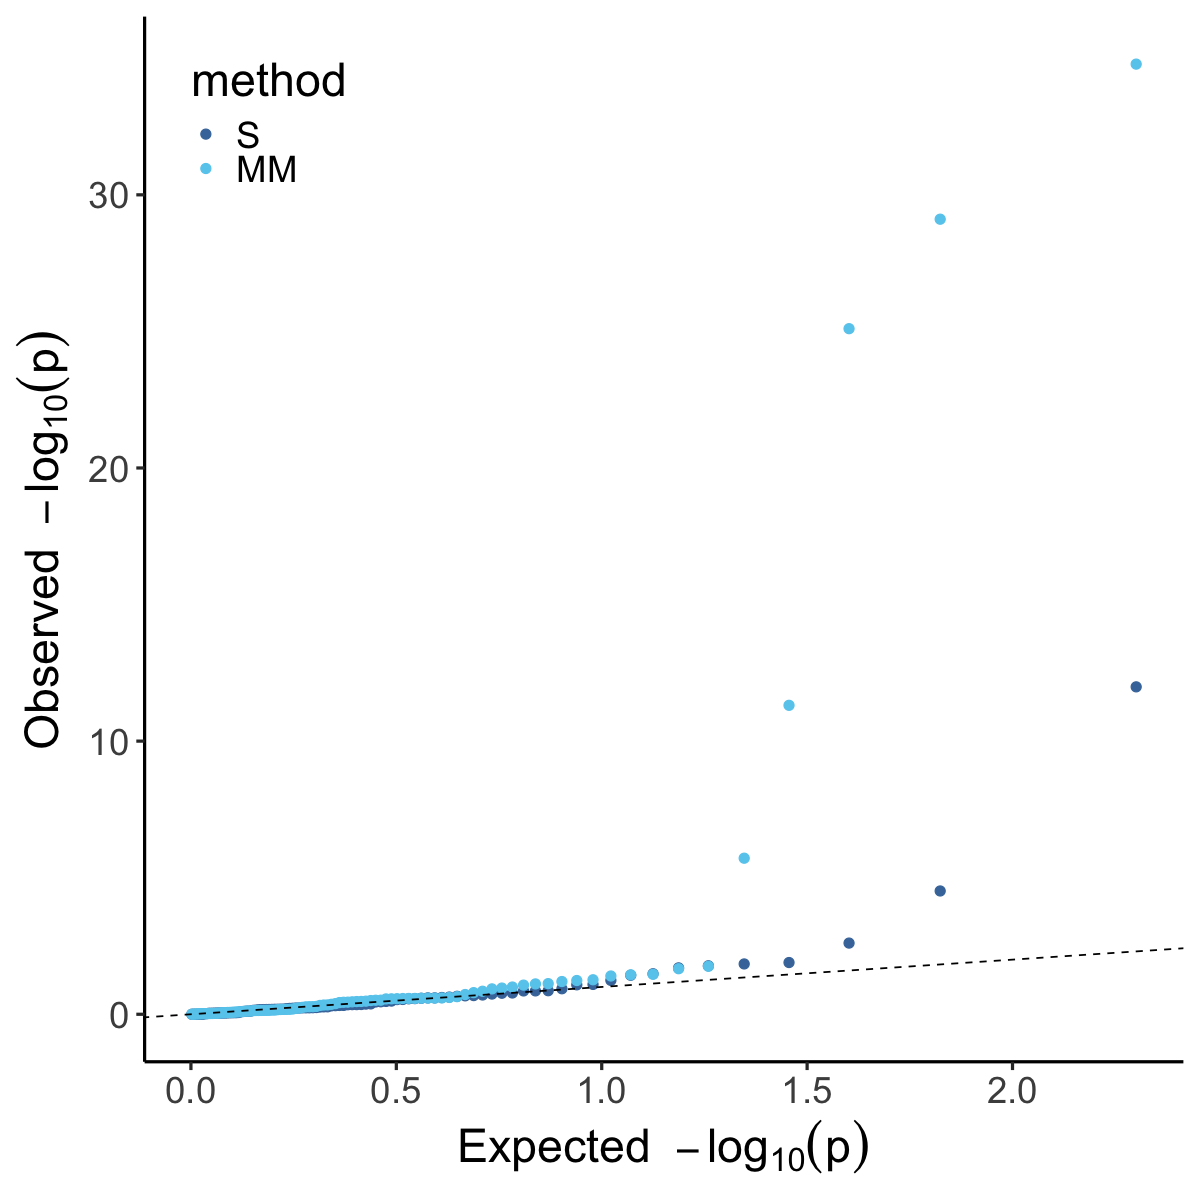

In [23]:
options(repr.plot.width = 10, repr.plot.height = 10)

qq_plot

ggsave("Figures_raw/PIC_qq.pdf", qq_plot, width = 10, height = 10)
ggsave("Figures_raw/PIC_qq.svg", qq_plot, width = 10, height = 10)

### 2. Yule tree with multiple shifts

In [25]:
library(tidyverse)
library(ape)
library(TreeSim)
library(phytools)
library(phylolm)
library(TreeTools)
library(tibble)
library(dplyr)
library(readr)
library(data.table)
library(gridExtra)
library(svglite)
library(RColorBrewer)
library(viridis)
library(cowplot)

In [26]:
set.seed(19)
yule_tree = sim.bd.taxa(16, 1, 1, 0, 1, complete = FALSE)[[1]]
yule_tree$root.edge=0

shifts = 10^(seq(log10(1e-4),log10(1e4), len=10))

num_rep = 100
n_edges = length(yule_tree$edge) / 2
n_tips = n_edges / 2 + 1
yule_tree_l = sum(yule_tree$edge.length)
probs = yule_tree$edge.length / yule_tree_l

n_rows = length(shifts) * num_rep * 2

In [27]:
p_vals_4 = data.table(
    p.value = numeric(n_rows),  
    shifts = numeric(n_rows),
    method = character(n_rows)
)

counter = 1
set.seed(19)

for (i in 1:length(shifts)) {
    message("Testing for shift size: ", i)
    shift = shifts[i]

    e_1 = yule_tree$edge[1,]
    descendants_1 = getDescendants(yule_tree, e_1[2])
    descendants_tips_1 = descendants_1[descendants_1 <= n_tips]
    e_2 = yule_tree$edge[2,]
    descendants_2 = getDescendants(yule_tree, e_2[2])
    descendants_tips_2 = descendants_2[descendants_2 <= n_tips]
    e_3 = yule_tree$edge[23,]
    descendants_3 = getDescendants(yule_tree, e_3[2])
    descendants_tips_3 = descendants_3[descendants_3 <= n_tips]
    e_4 = yule_tree$edge[25,]
    descendants_4 = getDescendants(yule_tree, e_4[2])
    descendants_tips_4 = descendants_4[descendants_4 <= n_tips]

    for (m in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]  
        X[descendants_tips_1] = X[descendants_tips_1] + rnorm(1,0,sd=sqrt(shift))
        Y[descendants_tips_1] = Y[descendants_tips_1] + rnorm(1,0,sd=sqrt(shift))
        X[descendants_tips_2] = X[descendants_tips_2] + rnorm(1,0,sd=sqrt(shift))
        Y[descendants_tips_2] = Y[descendants_tips_2] + rnorm(1,0,sd=sqrt(shift))
        X[descendants_tips_3] = X[descendants_tips_3] + rnorm(1,0,sd=sqrt(shift))
        Y[descendants_tips_3] = Y[descendants_tips_3] + rnorm(1,0,sd=sqrt(shift))
        X[descendants_tips_4] = X[descendants_tips_4] + rnorm(1,0,sd=sqrt(shift))
        Y[descendants_tips_4] = Y[descendants_tips_4] + rnorm(1,0,sd=sqrt(shift))
            
        pic_X = pic(X, yule_tree)
        pic_Y = pic(Y, yule_tree)
            
        all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, estim = "Initial")
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_4[counter, `:=`("p.value" = cur_p, "shifts" = shift, "method" = "S")]

        counter = counter + 1 

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                        control = lmRob.control(mxr = 1e8))
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_4[counter, `:=`("p.value" = cur_p, "shifts" = shift, "method" = "MM")]

        counter = counter + 1                           
    }  
}

Testing for shift size: 1

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test

In [28]:
p_vals_summary_4 = p_vals_4 %>% group_by(method, shifts) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")
p_vals_summary_4$sd.shift = sqrt(p_vals_summary_4$shifts)

p_vals_summary_4 = as.data.table(p_vals_summary_4)

In [71]:
plot_shift_4 <- p_vals_summary_4 %>% 
    ggplot(aes(sd.shift, FPR, color = method)) +
    geom_line(linewidth=2) +
    theme_classic(base_size=20) +
    xlab("sd(shift)") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) + 
    theme(legend.position=c(.15,.85),legend.spacing.y = unit(1,"pt"), 
          axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.title = element_text(size = 36), legend.text = element_text(size = 32)) + 
    scale_color_manual(values = c("#4477AA","#66CCEE"), 
                     breaks = c("S", "MM")) + 
    scale_x_continuous(trans = 'log10')

In [30]:
p_vals_8 = data.table(
    p.value = numeric(n_rows),  
    shifts = numeric(n_rows),
    method = character(n_rows)
)

counter = 1
set.seed(19)

cand_edges = c(1, 2, 11, 15, 17, 23, 25, 26)
n_cand_edges = length(cand_edges)

for (i in 1:length(shifts)) {
    message("Testing for shift size: ", i)
    shift = shifts[i]

    descendants_tips_list <- vector("list", n_cand_edges)
    for (j in 1:n_cand_edges) {
        id_cand = cand_edges[j]
        e_cand = yule_tree$edge[id_cand,]
        descendants_cand = getDescendants(yule_tree, e_cand[2])
        descendants_tips_list[[j]] = descendants_cand[descendants_cand <= n_tips]
    }

    for (m in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]
        for (j in 1:n_cand_edges) {
            descendants_tips = descendants_tips_list[[j]]
            X[descendants_tips] = X[descendants_tips] + rnorm(1,0,sd=sqrt(shift))
            Y[descendants_tips] = Y[descendants_tips] + rnorm(1,0,sd=sqrt(shift))
        }
            
        pic_X = pic(X, yule_tree)
        pic_Y = pic(Y, yule_tree)
            
        all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, estim = "Initial")
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_8[counter, `:=`("p.value" = cur_p, "shifts" = shift, "method" = "S")]

        counter = counter + 1 

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                        control = lmRob.control(mxr = 1e8))
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_8[counter, `:=`("p.value" = cur_p, "shifts" = shift, "method" = "MM")]

        counter = counter + 1                         
    }  
}

Testing for shift size: 1

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Testing for shift size: 2

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Testing for shift size: 3

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than

In [31]:
p_vals_summary_8 = p_vals_8 %>% group_by(method, shifts) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")
p_vals_summary_8$sd.shift = sqrt(p_vals_summary_8$shifts)

p_vals_summary_8 = as.data.table(p_vals_summary_8)

In [61]:
plot_shift_8 <- p_vals_summary_8 %>% 
    ggplot(aes(sd.shift, FPR, color = method)) +
    geom_line(linewidth=2) +
    theme_classic(base_size=20) +
    xlab("sd(shift)") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) + 
    theme(legend.position=c(.15,.85),legend.spacing.y = unit(1,"pt"), 
          axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.title = element_text(size = 36), legend.text = element_text(size = 32)) + 
    scale_color_manual(values = c("#4477AA","#66CCEE"), 
                     breaks = c("S", "MM")) + 
    scale_x_continuous(trans = 'log10')

In [33]:
p_vals_12 = data.table(
    p.value = numeric(n_rows),  
    shifts = numeric(n_rows),
    method = character(n_rows)
)

counter = 1
set.seed(19)

cand_edges = c(1, 2, 9, 10, 11, 15, 17, 18, 23, 24, 25, 26)
n_cand_edges = length(cand_edges)

for (i in 1:length(shifts)) {
    message("Testing for shift size: ", i)
    shift = shifts[i]

    descendants_tips_list <- vector("list", n_cand_edges)
    for (j in 1:n_cand_edges) {
        id_cand = cand_edges[j]
        e_cand = yule_tree$edge[id_cand,]
        descendants_cand = getDescendants(yule_tree, e_cand[2])
        descendants_tips_list[[j]] = descendants_cand[descendants_cand <= n_tips]
    }

    for (m in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]
        for (j in 1:n_cand_edges) {
            descendants_tips = descendants_tips_list[[j]]
            X[descendants_tips] = X[descendants_tips] + rnorm(1,0,sd=sqrt(shift))
            Y[descendants_tips] = Y[descendants_tips] + rnorm(1,0,sd=sqrt(shift))
        }
            
        pic_X = pic(X, yule_tree)
        pic_Y = pic(Y, yule_tree)
            
        all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, estim = "Initial")
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_12[counter, `:=`("p.value" = cur_p, "shifts" = shift, "method" = "S")]

        counter = counter + 1 

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                        control = lmRob.control(mxr = 1e8))
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_12[counter, `:=`("p.value" = cur_p, "shifts" = shift, "method" = "MM")]

        counter = counter + 1                          
    }  
}

Testing for shift size: 1

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Testing for shift size: 2

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bia

In [34]:
p_vals_summary_12 = p_vals_12 %>% group_by(method, shifts) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")
p_vals_summary_12$sd.shift = sqrt(p_vals_summary_12$shifts)

p_vals_summary_12 = as.data.table(p_vals_summary_12)

In [62]:
plot_shift_12 <- p_vals_summary_12 %>% 
    ggplot(aes(sd.shift, FPR, color = method)) +
    geom_line(linewidth=2) +
    theme_classic(base_size=20) +
    xlab("sd(shift)") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) + 
    theme(legend.position=c(.15,.85),legend.spacing.y = unit(1,"pt"), 
          axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.title = element_text(size = 36), legend.text = element_text(size = 32)) + 
    scale_color_manual(values = c("#4477AA","#66CCEE"), 
                     breaks = c("S", "MM")) + 
    scale_x_continuous(trans = 'log10')

In [36]:
shifts_2 = sqrt(shifts)

p_vals_5 = data.table(
    p.value = numeric(n_rows),  
    shifts = numeric(n_rows),
    method = character(n_rows)
)

counter = 1
set.seed(19)

for (i in 1:length(shifts)) {
    message("Testing for shift size: ", i)
    shift = shifts_2[i]

    e_1 = yule_tree$edge[1,]
    descendants_1 = getDescendants(yule_tree, e_1[2])
    descendants_tips_1 = descendants_1[descendants_1 <= n_tips]
    e_2 = yule_tree$edge[2,]
    descendants_2 = getDescendants(yule_tree, e_2[2])
    descendants_tips_2 = descendants_2[descendants_2 <= n_tips]
    e_3 = yule_tree$edge[23,]
    descendants_3 = getDescendants(yule_tree, e_3[2])
    descendants_tips_3 = descendants_3[descendants_3 <= n_tips]
    e_4 = yule_tree$edge[25,]
    descendants_4 = getDescendants(yule_tree, e_4[2])
    descendants_tips_4 = descendants_4[descendants_4 <= n_tips]


    for (m in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]  
        X[descendants_tips_1] = X[descendants_tips_1] + shift
        Y[descendants_tips_1] = Y[descendants_tips_1] + shift
        X[descendants_tips_2] = X[descendants_tips_2] + shift
        Y[descendants_tips_2] = Y[descendants_tips_2] + shift
        X[descendants_tips_3] = X[descendants_tips_3] + shift
        Y[descendants_tips_3] = Y[descendants_tips_3] + shift
        X[descendants_tips_4] = X[descendants_tips_4] + shift
        Y[descendants_tips_4] = Y[descendants_tips_4] + shift

        pic_X = pic(X, yule_tree)
        pic_Y = pic(Y, yule_tree)
            
        all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, estim = "Initial")
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_5[counter, `:=`("p.value" = cur_p, "shifts" = shift, "method" = "S")]

        counter = counter + 1 

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                        control = lmRob.control(mxr = 1e8))
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_5[counter, `:=`("p.value" = cur_p, "shifts" = shift, "method" = "MM")]

        counter = counter + 1            
                               
    }  
}

Testing for shift size: 1

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Testing for shift size: 2

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Testing for shift size: 3

Warning message in test.lmRob(object):
“Denominator smaller than

In [37]:
p_vals_summary_5 = p_vals_5 %>% group_by(method, shifts) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")

p_vals_summary_5 = as.data.table(p_vals_summary_5)

In [64]:
plot_shift_5 <- p_vals_summary_5 %>% 
    ggplot(aes(shifts, FPR, color = method)) +
    geom_line(linewidth=2) +
    theme_classic(base_size=20) +
    xlab("shift") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) + 
    theme(legend.position=c(.15,.85),legend.spacing.y = unit(1,"pt"), 
          axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.title = element_text(size = 36), legend.text = element_text(size = 32)) + 
    scale_color_manual(values = c("#4477AA","#66CCEE"), 
                     breaks = c("S", "MM")) + 
    scale_x_continuous(trans = 'log10')

In [39]:
p_vals_9 = data.table(
    p.value = numeric(n_rows),  
    shifts = numeric(n_rows),
    method = character(n_rows)
)

counter = 1
set.seed(19)

cand_edges = c(1, 2, 11, 15, 17, 23, 25, 26)
n_cand_edges = length(cand_edges)

for (i in 1:length(shifts_2)) {
    message("Testing for shift size: ", i)
    shift = shifts_2[i]

    descendants_tips_list <- vector("list", n_cand_edges)
    for (j in 1:n_cand_edges) {
        id_cand = cand_edges[j]
        e_cand = yule_tree$edge[id_cand,]
        descendants_cand = getDescendants(yule_tree, e_cand[2])
        descendants_tips_list[[j]] = descendants_cand[descendants_cand <= n_tips]
    }

    for (m in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]
        for (j in 1:n_cand_edges) {
            descendants_tips = descendants_tips_list[[j]]
            X[descendants_tips] = X[descendants_tips] + shift
            Y[descendants_tips] = Y[descendants_tips] + shift
        }
            
        pic_X = pic(X, yule_tree)
        pic_Y = pic(Y, yule_tree)
            
        all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, estim = "Initial")
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_9[counter, `:=`("p.value" = cur_p, "shifts" = shift, "method" = "S")]

        counter = counter + 1 

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                        control = lmRob.control(mxr = 1e8))
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_9[counter, `:=`("p.value" = cur_p, "shifts" = shift, "method" = "MM")]

        counter = counter + 1                             
    }  
}

Testing for shift size: 1

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Testing for shift size: 2

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bia

In [40]:
p_vals_summary_9 = p_vals_9 %>% group_by(method, shifts) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")

p_vals_summary_9 = as.data.table(p_vals_summary_9)

In [63]:
plot_shift_9 <- p_vals_summary_9 %>% 
    ggplot(aes(shifts, FPR, color = method)) +
    geom_line(linewidth=2) +
    theme_classic(base_size=20) +
    xlab("shift") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) + 
    theme(legend.position=c(.15,.85),legend.spacing.y = unit(1,"pt"), 
          axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.title = element_text(size = 36), legend.text = element_text(size = 32)) + 
    scale_color_manual(values = c("#4477AA","#66CCEE"), 
                     breaks = c("S", "MM")) + 
    scale_x_continuous(trans = 'log10')

In [42]:
p_vals_13 = data.table(
    p.value = numeric(n_rows),  
    shifts = numeric(n_rows),
    method = character(n_rows)
)

counter = 1
set.seed(19)

cand_edges = c(1, 2, 9, 10, 11, 15, 17, 18, 23, 24, 25, 26)
n_cand_edges = length(cand_edges)

for (i in 1:length(shifts_2)) {
    message("Testing for shift size: ", i)
    shift = shifts_2[i]

    descendants_tips_list <- vector("list", n_cand_edges)
    for (j in 1:n_cand_edges) {
        id_cand = cand_edges[j]
        e_cand = yule_tree$edge[id_cand,]
        descendants_cand = getDescendants(yule_tree, e_cand[2])
        descendants_tips_list[[j]] = descendants_cand[descendants_cand <= n_tips]
    }

    for (m in 1:num_rep) {
        BM = fastBM(yule_tree, 1, nsim=2)
        X = BM[,1]
        Y = BM[,2]
        for (j in 1:n_cand_edges) {
            descendants_tips = descendants_tips_list[[j]]
            X[descendants_tips] = X[descendants_tips] + shift
            Y[descendants_tips] = Y[descendants_tips] + shift
        }
            
        pic_X = pic(X, yule_tree)
        pic_Y = pic(Y, yule_tree)
            
        all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, estim = "Initial")
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_13[counter, `:=`("p.value" = cur_p, "shifts" = shift, "method" = "S")]

        counter = counter + 1 

        cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                        control = lmRob.control(mxr = 1e8))
        cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
        p_vals_13[counter, `:=`("p.value" = cur_p, "shifts" = shift, "method" = "MM")]

        counter = counter + 1                           
    }  
}

Testing for shift size: 1

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Testing for shift size: 2

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Testing for shift size: 3

Warning message in test.lmRob(object):
“Denominator smaller than

In [43]:
p_vals_summary_13 = p_vals_13 %>% group_by(method, shifts) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop")

p_vals_summary_13 = as.data.table(p_vals_summary_13)

In [65]:
plot_shift_13 <- p_vals_summary_13 %>% 
    ggplot(aes(shifts, FPR, color = method)) +
    geom_line(linewidth=2) +
    theme_classic(base_size=20) +
    xlab("shift") +
    ylab("Fraction of significant tests") +
    ylim(0, 1) + 
    geom_hline(yintercept=0.05,lty=2) + 
    theme(legend.position=c(.15,.85),legend.spacing.y = unit(1,"pt"), 
          axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.title = element_text(size = 36), legend.text = element_text(size = 32)) + 
    scale_color_manual(values = c("#4477AA","#66CCEE"), 
                     breaks = c("S", "MM")) + 
    scale_x_continuous(trans = 'log10')

TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name            grob
1 1 (1-1,1-1) arrange gtable[arrange]
2 2 (2-2,1-1) arrange gtable[arrange]

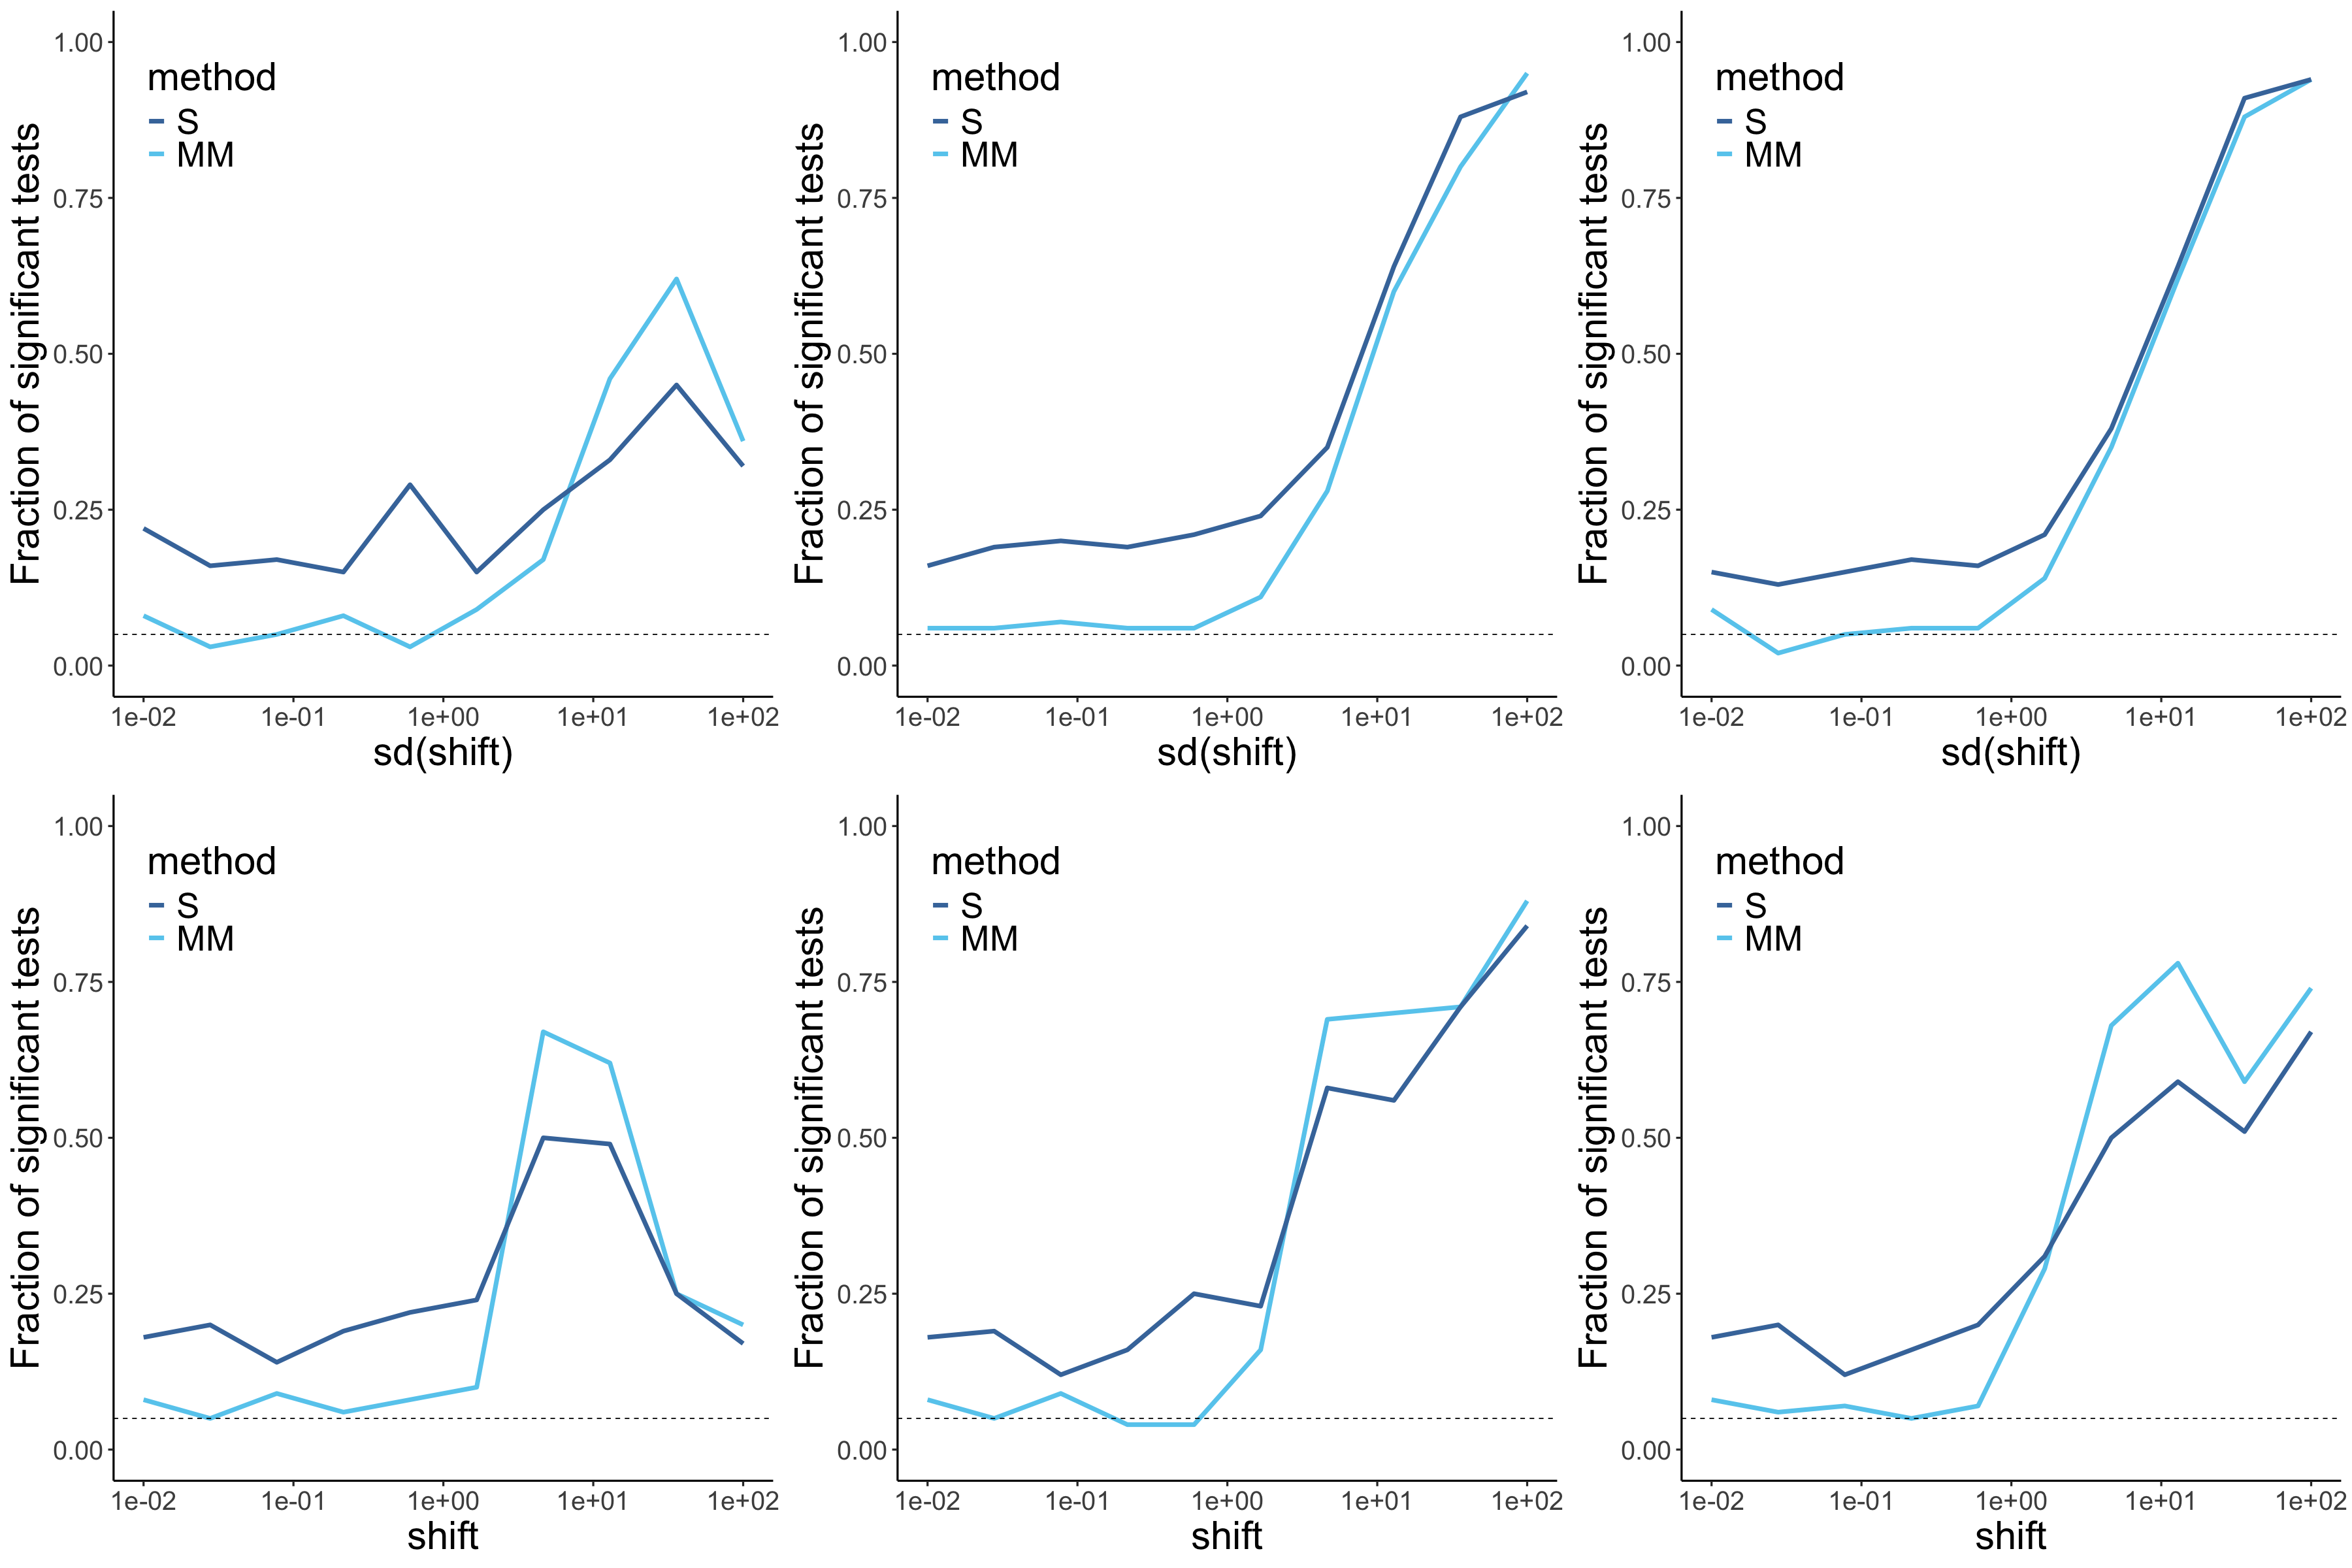

In [72]:
options(repr.plot.width = 30, repr.plot.height = 20)

row1 <- arrangeGrob(plot_shift_4,plot_shift_8, plot_shift_12, ncol = 3)
row2 <- arrangeGrob(plot_shift_5, plot_shift_9, plot_shift_13, ncol = 3)

# Arrange all rows into one layout
g <- grid.arrange(row1, row2, nrow = 2)
g
ggsave("Figures_raw/PIC_FPR.pdf", g, width = 30, height = 20)
ggsave("Figures_raw/PIC_FPR.svg", g, width = 30, height = 20)

### 3. Power

In [73]:
num_rep = 100
n_tips = 2 ** c(3:10)
n_size = length(n_tips)
betas = 2 ** c(-4:4)
n_beta = length(betas)
n_rows = num_rep * n_size * n_beta * 2

In [74]:
p_vals = data.table(
    p.value = numeric(n_rows), 
    method = character(n_rows), 
    n.tips = numeric(n_rows), 
    beta.size = numeric(n_rows)
)

set.seed(42)

counter = 1
for (i in 1:n_size) {
    message("Testing for tip number: ", i)
    n_tip = n_tips[i]

    tree = sim.bd.taxa(n_tip,1,1,0,1,complete=FALSE)[[1]]
    tree$root.edge=0 

    for (j in 1:num_rep) {
        if (j %% 10 == 0) {message("repeat: ", j)}
        
        for (k in 1:n_beta) {
            beta = betas[k]

            BM = fastBM(tree,1,nsim=2)
            X = BM[,1]
            Y = X * beta + BM[,2]
    
            pic_X = pic(X, tree)
            pic_Y = pic(Y, tree)
            
            all_data = as.data.frame(tibble(pic_X = pic_X, pic_Y = pic_Y))

            cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, estim = "Initial")
            cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
            p_vals[counter, `:=`("p.value" = cur_p, "method" = "S", 
                                 "n.tips" = n_tip, "beta.size" = beta)]

            counter = counter + 1 

            cur_rlm = lmRob(pic_Y ~ pic_X - 1, data = all_data, 
                            control = lmRob.control(mxr = 1e8))
            cur_p = summary(cur_rlm)$coefficients["pic_X", "Pr(>|t|)"]
            p_vals[counter, `:=`("p.value" = cur_p, "method" = "MM", 
                                 "n.tips" = n_tip, "beta.size" = beta)]

            counter = counter + 1      
            
       }
    
    }
}

Testing for tip number: 1

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
repeat: 10

Warning message in test.lmRob(object):
“Denominator smaller than tl= 1e-06  in test for bias.”
Warning mes

In [200]:
p_vals_summary = p_vals %>% group_by(method, n.tips, beta.size) %>%
    summarise(FNR = mean(p.value<0.05), .groups = "drop")
    
p_vals_summary$n.tips = factor(p_vals_summary$n.tips)
p_vals_summary$method = factor(p_vals_summary$method)

plot_positive <- p_vals_summary %>% 
    ggplot(aes(beta.size, FNR)) +
    geom_line(aes(color = n.tips, linetype = method), linewidth=2) +
    theme_classic(base_size=20) +
    xlab(expression(beta)) +
    ylab("Fraction of significant tests") + 
    scale_x_continuous(trans = 'log2') +
    ylim(0, 1) +
    theme(legend.position=c(.88,.25), legend.spacing.y = unit(1,"pt"), 
          legend.key.width = unit(2, "cm"),
          axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
          axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
          legend.title = element_text(size = 24), legend.text = element_text(size = 18)) +
    scale_color_manual(values=c("#332288", "#88CCEE", "#44AA99", "#117733",
                                "#999933", "#DDCC77", "#CC6677", "#882255"), 
                       breaks = c("8", "16","32", "64", "128", "256", "512", "1024")) +
    scale_linetype_manual(values = c("solid", "twodash"), breaks = c("S", "MM")) +
    guides(color = guide_legend(order = 2),
    linetype = guide_legend(order = 1))

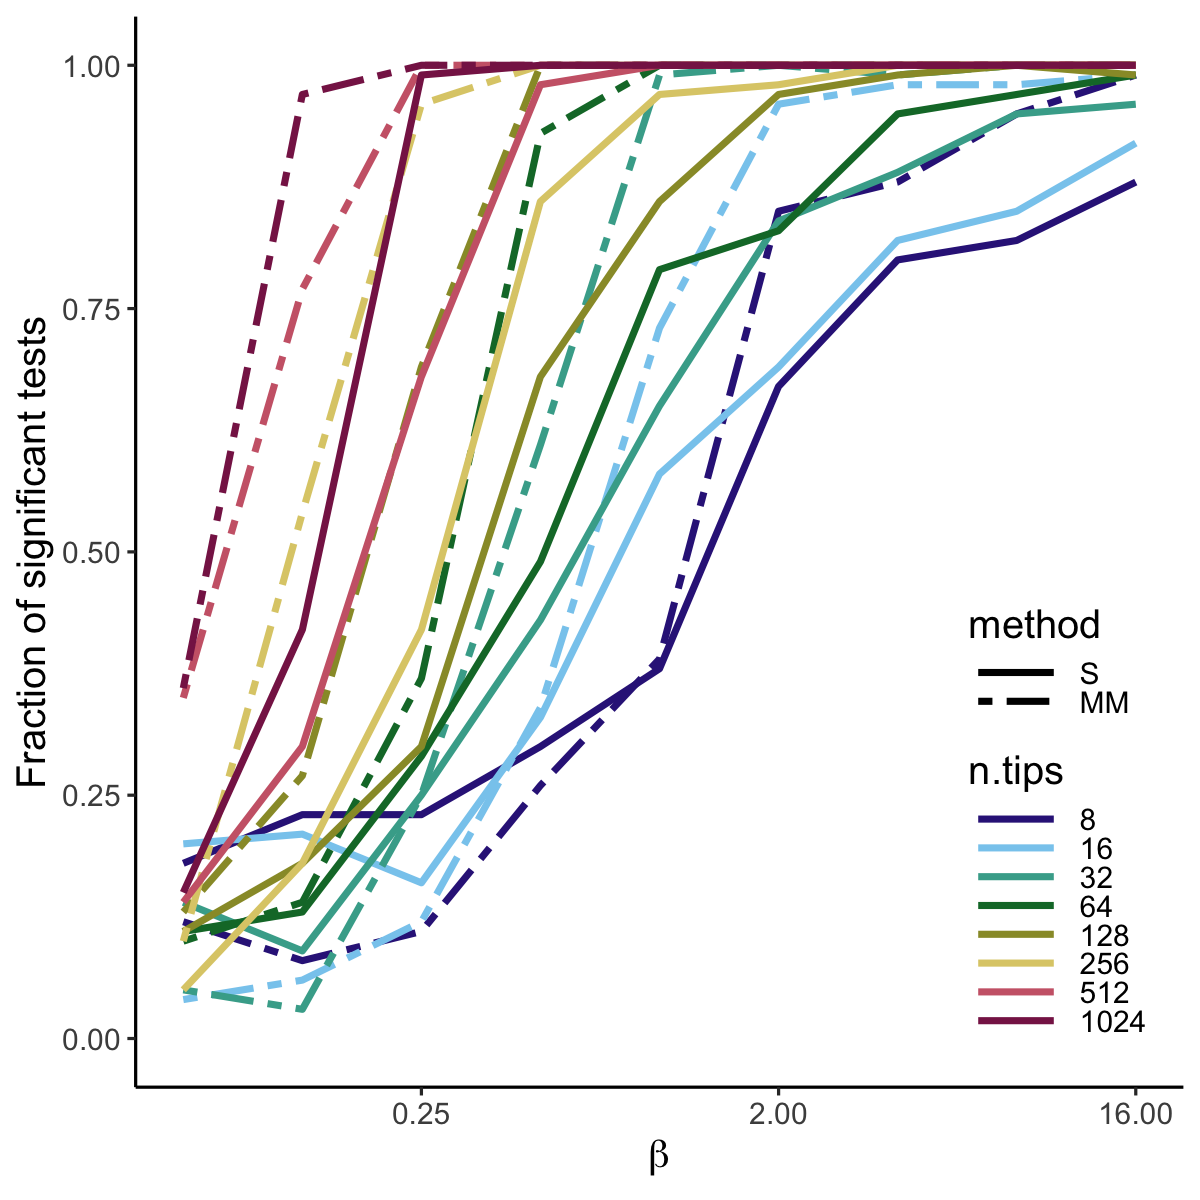

In [202]:
options(repr.plot.width = 10, repr.plot.height = 10)

plot_positive

In [85]:
p_vals_summary = p_vals %>% group_by(method, n.tips, beta.size) %>%
    summarise(FNR = mean(p.value<0.05), .groups = "drop")
    
p_vals_summary$n.tips = factor(p_vals_summary$n.tips)
p_vals_summary$method = factor(p_vals_summary$method)

p_vals_summary_S = p_vals_summary %>% filter(method == "S")
p_vals_summary_MM = p_vals_summary %>% filter(method == "MM")

plot_positive_S <- p_vals_summary_S %>% 
    ggplot(aes(beta.size, FNR)) +
    geom_line(aes(color = n.tips), linewidth=2) +
    theme_classic(base_size=20) +
    xlab(expression(beta)) +
    ylab("Fraction of significant tests") + 
    scale_x_continuous(trans = 'log2', breaks = 2^(-4:4), 
                       labels = function(x) parse(text = paste0("2^", log2(x)))) +
    ylim(0, 1) +
    theme(legend.position=c(.88,.22), legend.spacing.y = unit(1,"pt"), 
          legend.key.width = unit(2, "cm"),
          axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
    scale_color_manual(values=c("#332288", "#88CCEE", "#44AA99", "#117733",
                                "#999933", "#DDCC77", "#CC6677", "#882255"), 
                       breaks = c("8", "16","32", "64", "128", "256", "512", "1024"))

In [86]:
plot_positive_MM <- p_vals_summary_MM %>% 
    ggplot(aes(beta.size, FNR)) +
    geom_line(aes(color = n.tips), linewidth=2) +
    theme_classic(base_size=20) +
    xlab(expression(beta)) +
    ylab("Fraction of significant tests") + 
    scale_x_continuous(trans = 'log2', breaks = 2^(-4:4), 
                       labels = function(x) parse(text = paste0("2^", log2(x)))) +
    ylim(0, 1) +
    theme(legend.position=c(.88,.22), legend.spacing.y = unit(1,"pt"), 
          legend.key.width = unit(2, "cm"),
          axis.title.x = element_text(size = 36), axis.title.y = element_text(size = 36), 
          axis.text.x = element_text(size = 24), axis.text.y = element_text(size = 24),
          legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
    scale_color_manual(values=c("#332288", "#88CCEE", "#44AA99", "#117733",
                                "#999933", "#DDCC77", "#CC6677", "#882255"), 
                       breaks = c("8", "16","32", "64", "128", "256", "512", "1024"))

TableGrob (1 x 1) "arrange": 1 grobs
  z     cells    name            grob
1 1 (1-1,1-1) arrange gtable[arrange]

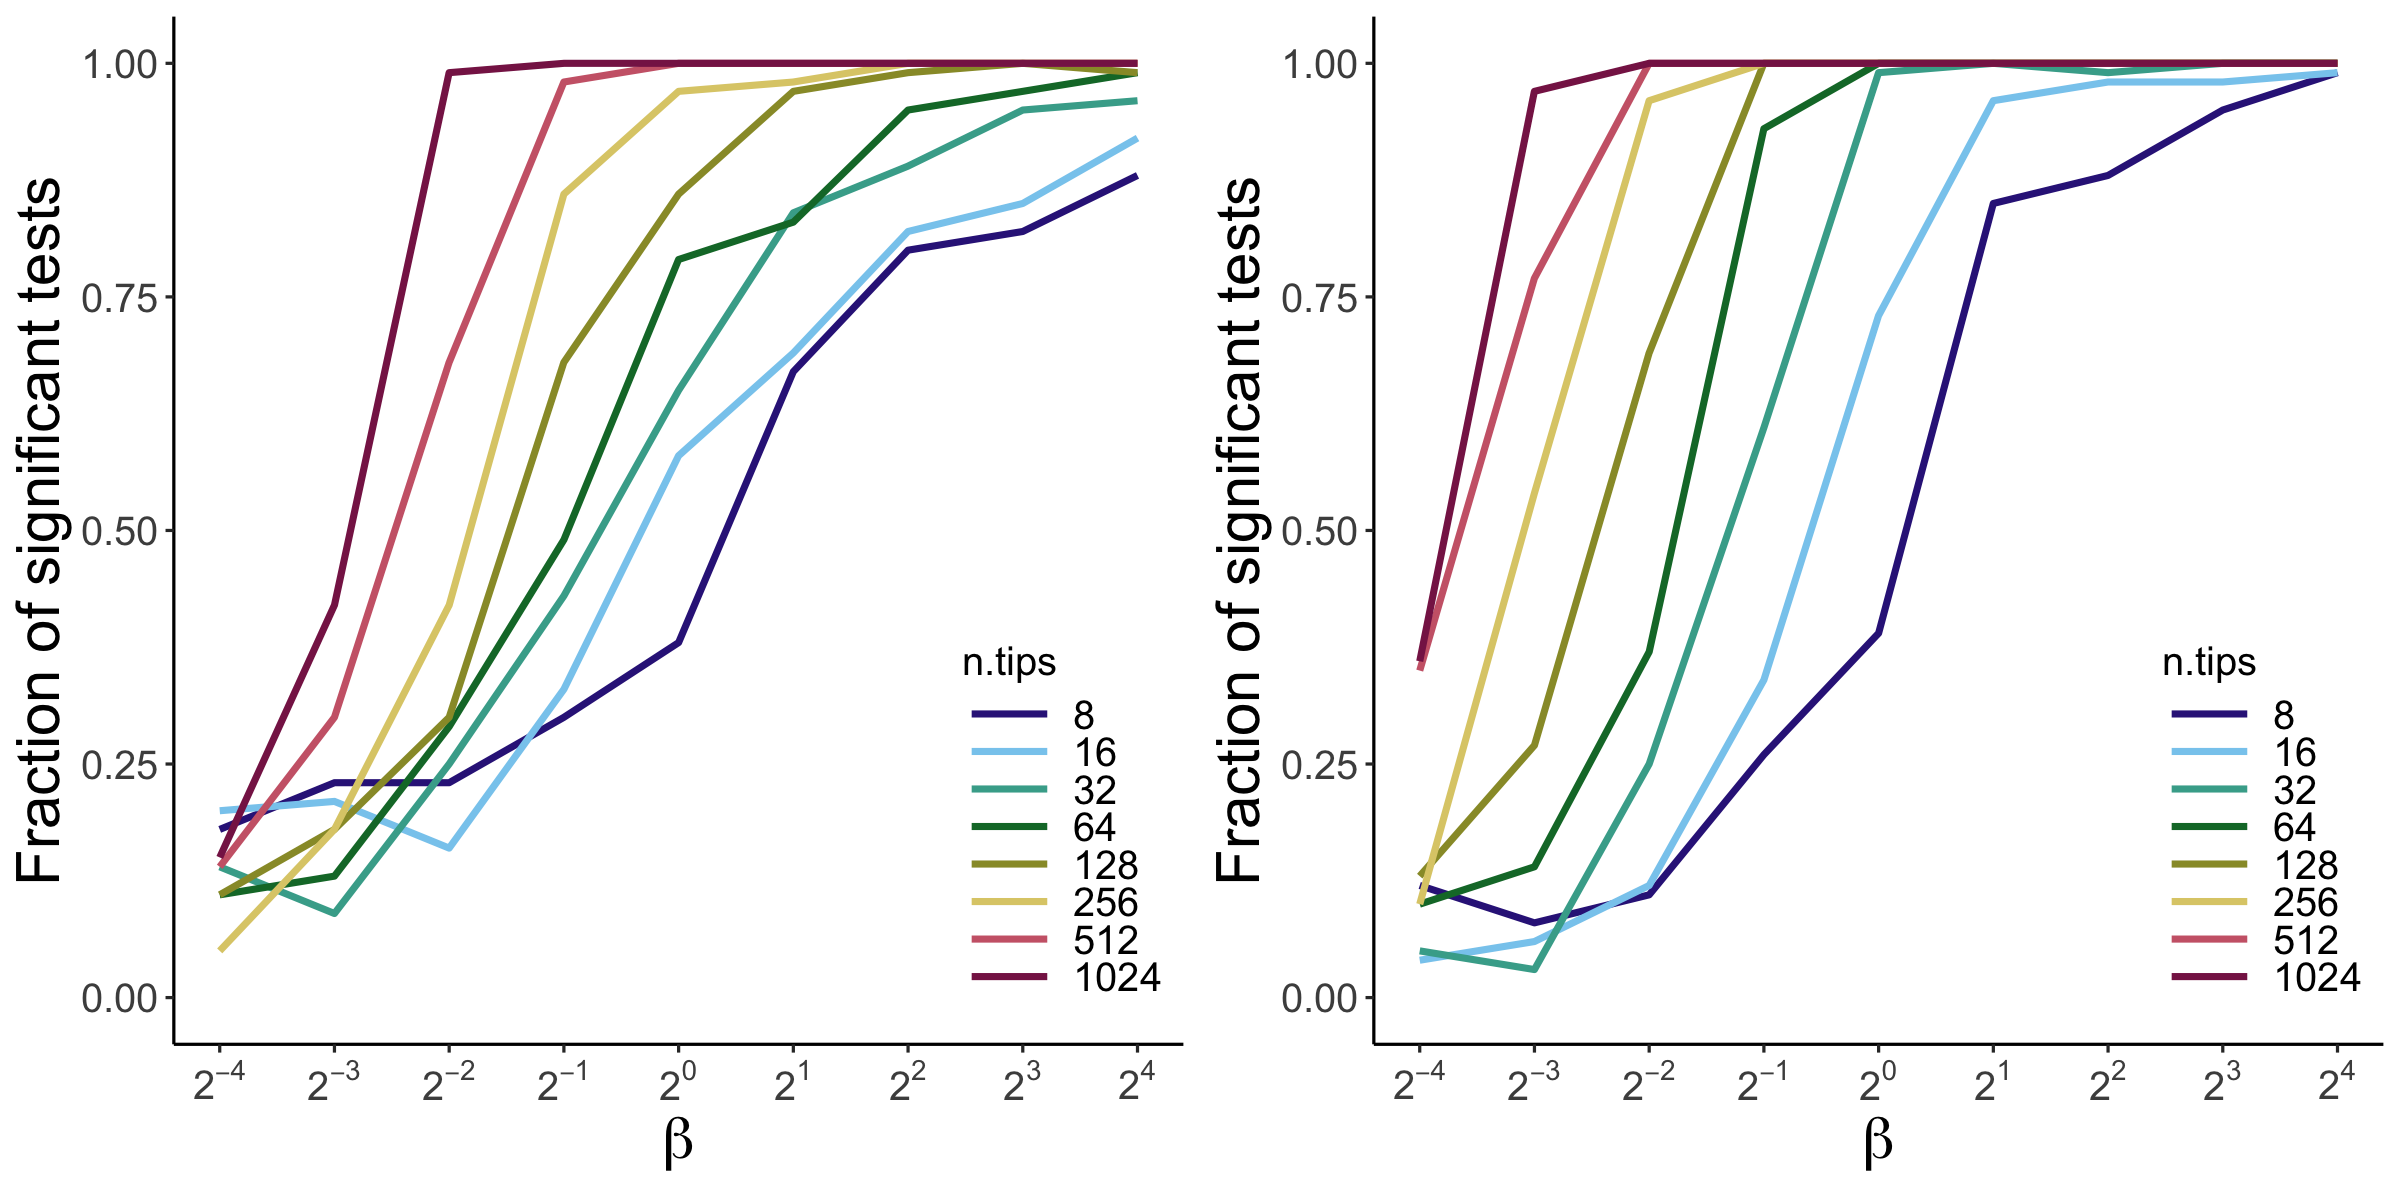

In [88]:
options(repr.plot.width = 20, repr.plot.height = 10)

row1 <- arrangeGrob(plot_positive_S, plot_positive_MM, ncol = 2)

# Arrange all rows into one layout
g <- grid.arrange(row1, nrow = 1)
g
ggsave("Figures_raw/PIC_power.pdf", g, width = 20, height = 10)
ggsave("Figures_raw/PIC_power.svg", g, width = 20, height = 10)